<a href="https://colab.research.google.com/github/mar25-iia2-radiographies/01_data_exploration/blob/main/02_radiographie_covid_classification_LR_Houssein.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from glob import glob
from tqdm import tqdm
from sklearn.model_selection import train_test_split

import torch

# Seed pour reproductibilité
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️ Device: {device}")
if torch.cuda.is_available():
    print(f"🎮 GPU: {torch.cuda.get_device_name(0)}")
    print(f"💾 VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

🖥️ Device: cpu


In [6]:
# ==================== CONFIGURATION ====================

# Taille originale des images du dataset
ORIGINAL_SIZE = 299

# Hyperparamètres d'entraînement
IMG_SIZE = 64              # Taille d'entrée

# Preprocessing (conclusions notebook 02)
APPLY_CLAHE = True          # CLAHE améliore le contraste
CLAHE_CLIP_LIMIT = 2.0
CLAHE_TILE_SIZE = (8, 8)

# Seuils outliers (ajustés notebook 02)
OUTLIER_LOW = 65
OUTLIER_HIGH = 190

# Catégories à utiliser (toutes pour la segmentation)
CATEGORIES = ['COVID', 'Normal', 'Lung_Opacity', 'Viral Pneumonia']

print("✅ Configuration chargée")
print(f"   - Taille originale: {ORIGINAL_SIZE}x{ORIGINAL_SIZE}")
print(f"   - Taille réseau: {IMG_SIZE}x{IMG_SIZE}")
print(f"   - CLAHE: {APPLY_CLAHE}")

✅ Configuration chargée
   - Taille originale: 299x299
   - Taille réseau: 64x64
   - CLAHE: True


In [7]:
import kagglehub

# Téléchargement du dataset
path = kagglehub.dataset_download("tawsifurrahman/covid19-radiography-database")
base_path = Path(path)
data_path = base_path / "COVID-19_Radiography_Dataset"

print(f"✅ Dataset téléchargé: {base_path}")
print(f"📁 Data path: {data_path}")

100%|██████████| 778M/778M [00:26<00:00, 31.0MB/s]

Extracting files...


✅ Dataset téléchargé: /root/.cache/kagglehub/datasets/tawsifurrahman/covid19-radiography-database/versions/5
📁 Data path: /root/.cache/kagglehub/datasets/tawsifurrahman/covid19-radiography-database/versions/5/COVID-19_Radiography_Dataset


In [8]:
# Initialize an empty dictionary to store image paths
image_paths = {}

# Construct paths for 'images' and 'masks' for each category
for category in CATEGORIES:
    # Path for images
    image_dir = os.path.join(data_path, category, 'images')
    image_paths[f'{category}_images'] = image_dir

    # Path for masks
    mask_dir = os.path.join(data_path, category, 'masks')
    image_paths[f'{category}_masks'] = mask_dir

# Print the image_paths dictionary to verify
print("Image Paths Dictionary:")
for key, value in image_paths.items():
    print(f"{key}: {value}")

Image Paths Dictionary:
COVID_images: /root/.cache/kagglehub/datasets/tawsifurrahman/covid19-radiography-database/versions/5/COVID-19_Radiography_Dataset/COVID/images
COVID_masks: /root/.cache/kagglehub/datasets/tawsifurrahman/covid19-radiography-database/versions/5/COVID-19_Radiography_Dataset/COVID/masks
Normal_images: /root/.cache/kagglehub/datasets/tawsifurrahman/covid19-radiography-database/versions/5/COVID-19_Radiography_Dataset/Normal/images
Normal_masks: /root/.cache/kagglehub/datasets/tawsifurrahman/covid19-radiography-database/versions/5/COVID-19_Radiography_Dataset/Normal/masks
Lung_Opacity_images: /root/.cache/kagglehub/datasets/tawsifurrahman/covid19-radiography-database/versions/5/COVID-19_Radiography_Dataset/Lung_Opacity/images
Lung_Opacity_masks: /root/.cache/kagglehub/datasets/tawsifurrahman/covid19-radiography-database/versions/5/COVID-19_Radiography_Dataset/Lung_Opacity/masks
Viral Pneumonia_images: /root/.cache/kagglehub/datasets/tawsifurrahman/covid19-radiography-d


Displaying samples for category: COVID


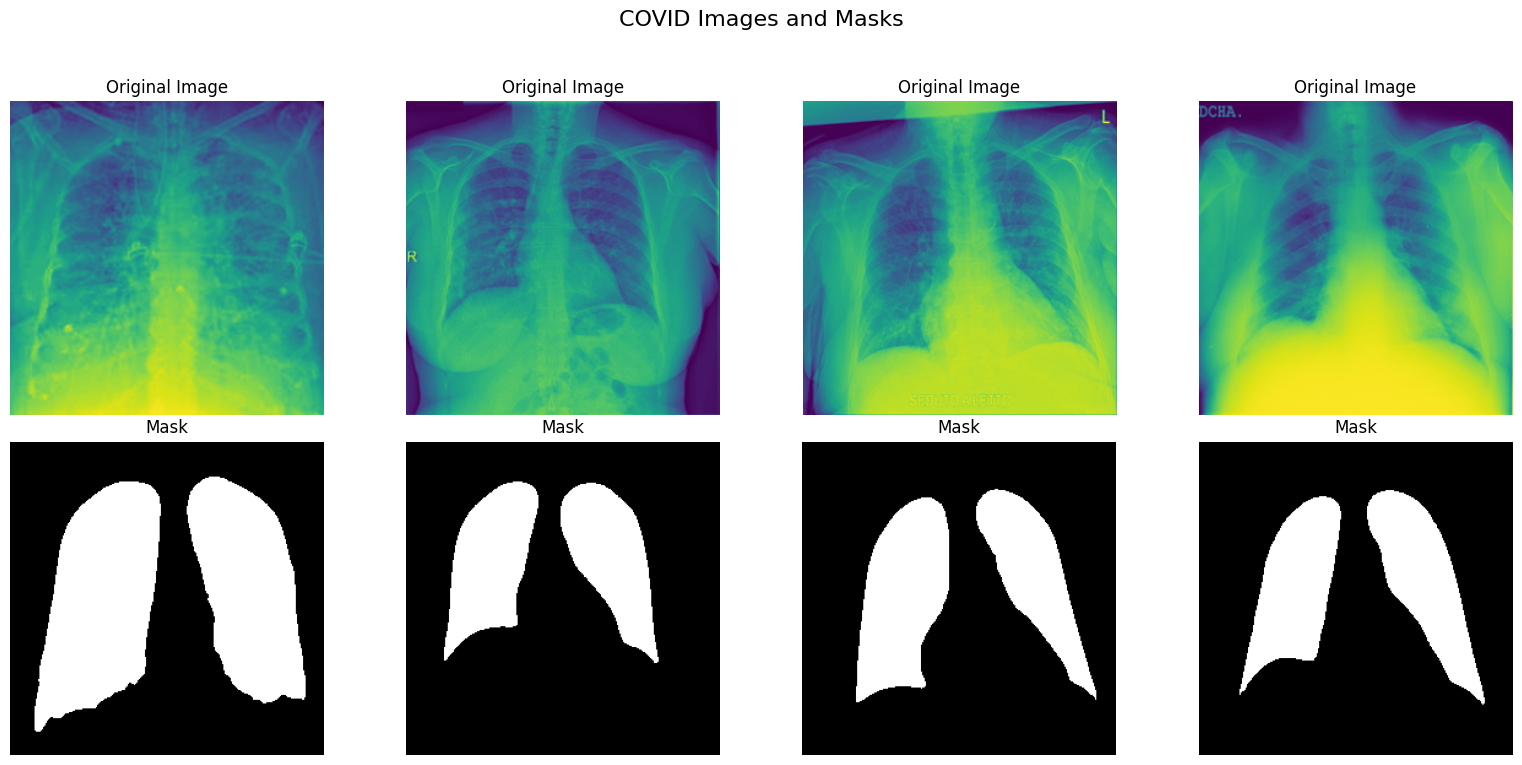


Displaying samples for category: Normal


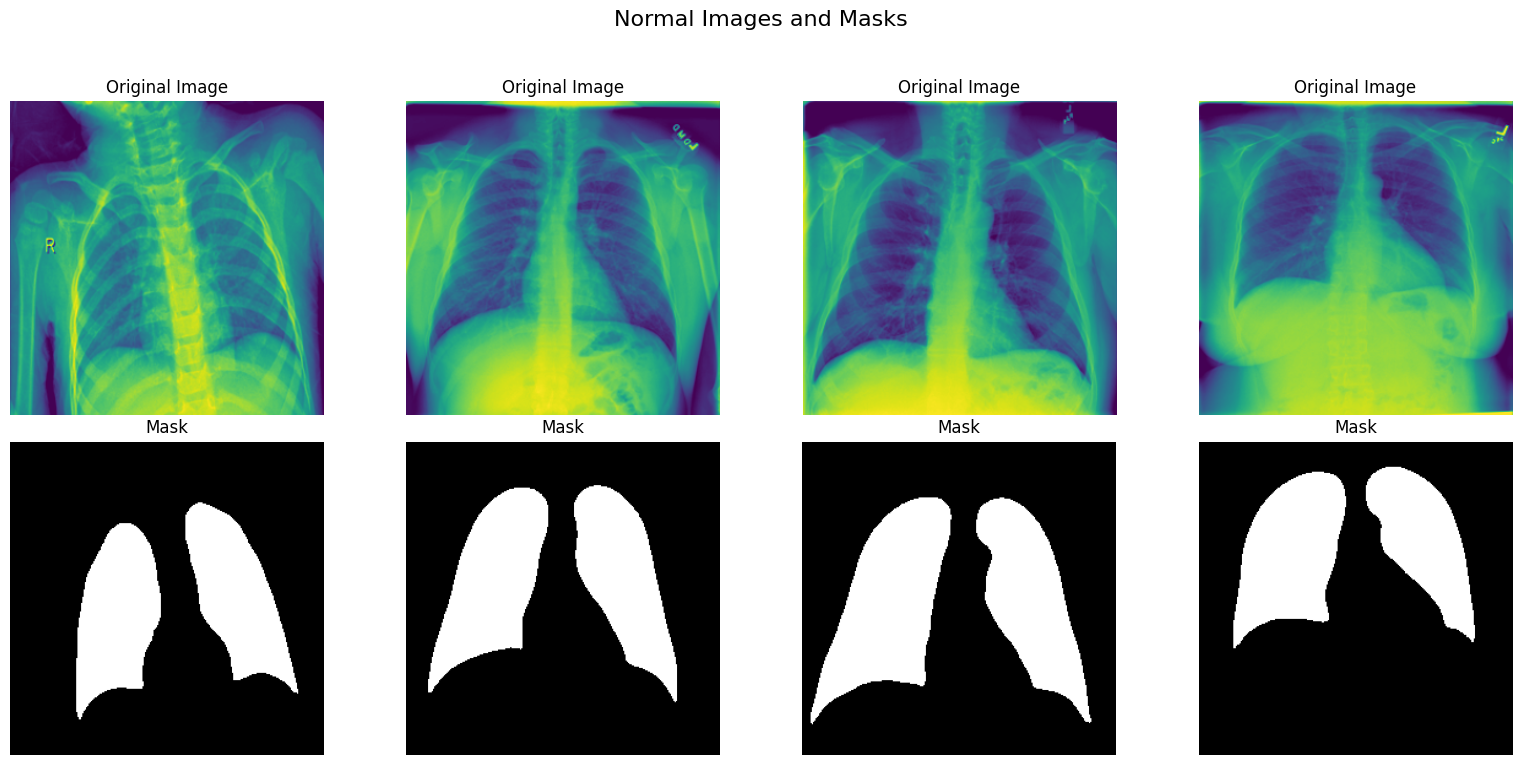


Displaying samples for category: Lung_Opacity


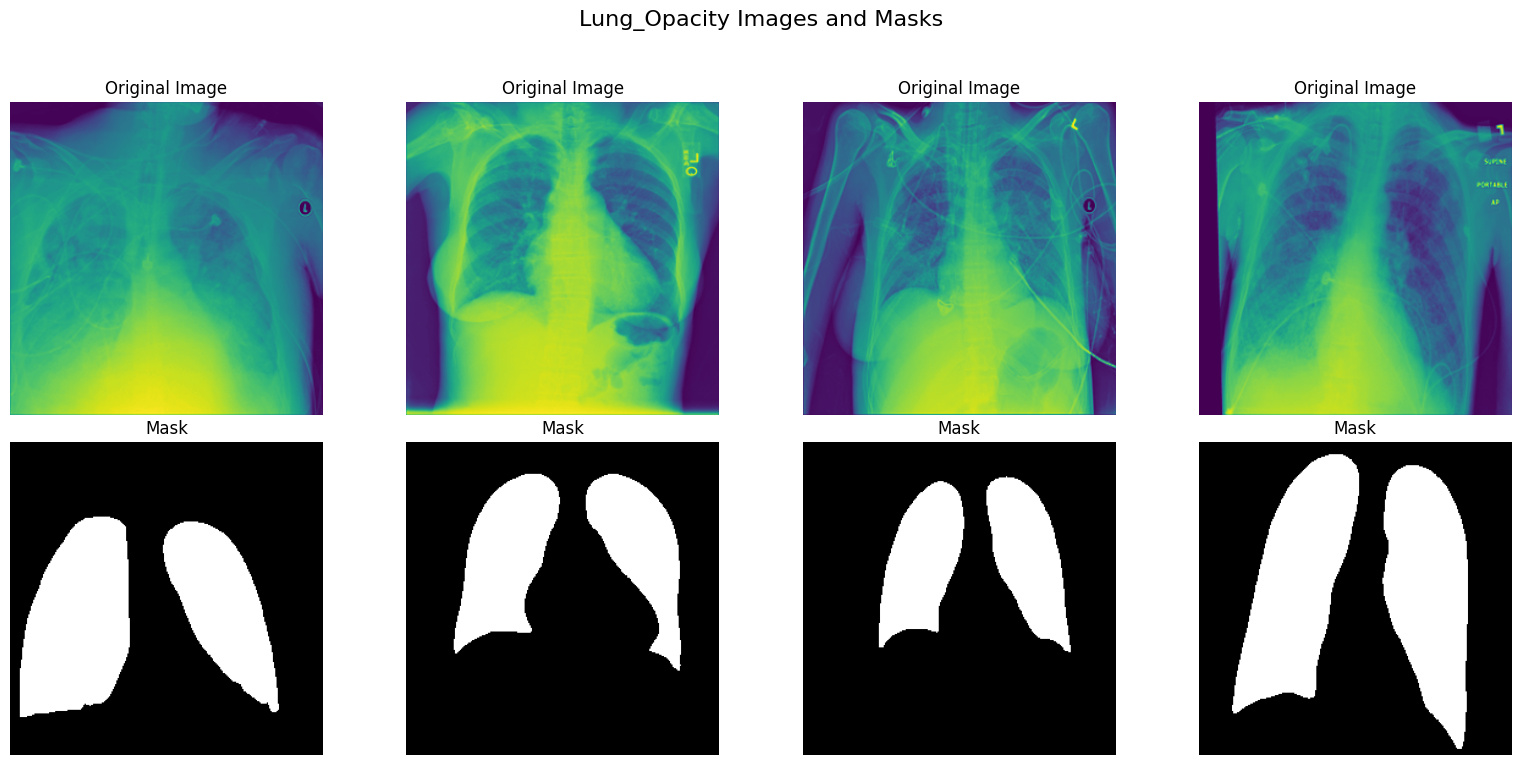


Displaying samples for category: Viral Pneumonia


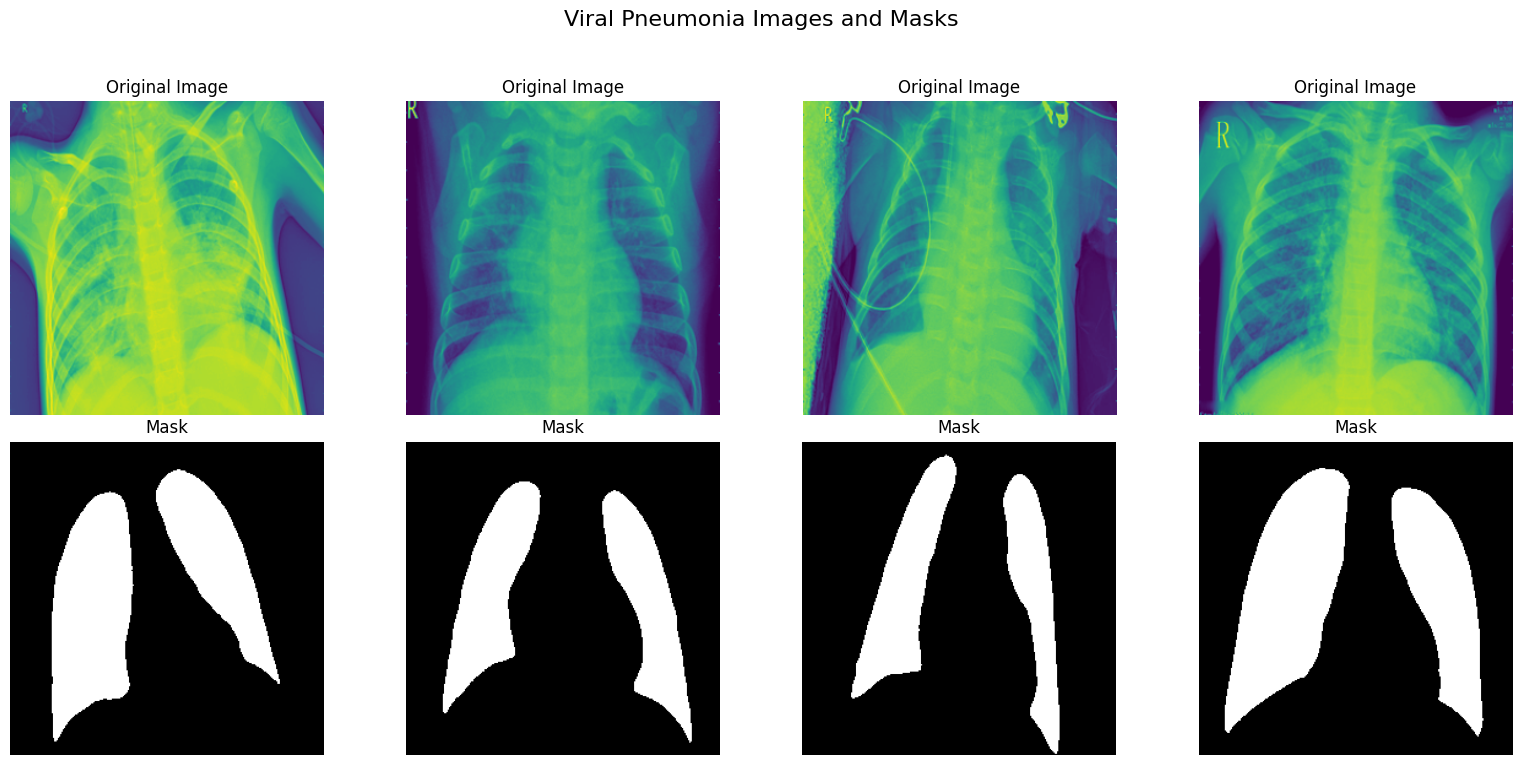

In [9]:
import random
import matplotlib.pyplot as plt
import cv2
import os

# On suppose que 'CATEGORIES' et 'image_paths' ont déjà été définis aux étapes précédentes
# CATEGORIES = ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']
# image_paths = { ... dictionnaire rempli ... }

# Boucle sur chaque catégorie pour afficher des exemples d'images et de masques
for category in CATEGORIES:
    print(f"\nDisplaying samples for category: {category}")

    # Récupérer les répertoires des images et des masques pour la catégorie courante
    current_image_dir = image_paths[f'{category}_images']
    current_mask_dir = image_paths[f'{category}_masks']

    # Obtenir la liste de tous les fichiers image dans la catégorie courante
    all_image_files = [
        f for f in os.listdir(current_image_dir)
        if f.endswith(('.png', '.jpg', '.jpeg'))
    ]

    # Sélectionner aléatoirement 4 fichiers image
    # S'assurer de ne pas sélectionner plus de fichiers qu'il n'en existe
    num_samples = min(4, len(all_image_files))
    selected_image_files = random.sample(all_image_files, num_samples)

    # Créer une figure avec une grille 2 x num_samples de sous-graphiques
    fig = plt.figure(figsize=(4 * num_samples, 8))
    fig.suptitle(f'{category} Images and Masks', fontsize=16)

    # # Si aucune image n'est trouvée pour cette catégorie, on peut ignorer l'affichage
    # if num_samples == 0:
    #     print(f"Aucune image trouvée pour la catégorie {category}.")
    #     plt.close(fig)
    #     continue

    for i, img_filename in enumerate(selected_image_files):
        # Construire les chemins complets pour l'image et le masque
        image_path = os.path.join(current_image_dir, img_filename)
        mask_path = os.path.join(current_mask_dir, img_filename)  # On suppose que le masque porte le même nom de fichier

        # Charger l'image
        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

        # Charger le masque (s'il existe)
        mask = None
        if os.path.exists(mask_path):
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        else:
            print(f"Warning: Mask not found for {img_filename} in {category}.")

        # Afficher l'image originale sur la première ligne
        plt.subplot(2, num_samples, i + 1)
        plt.imshow(img)
        plt.title('Original Image')
        plt.axis('off')

        # Afficher le masque sur la deuxième ligne
        plt.subplot(2, num_samples, num_samples + i + 1)
        if mask is not None:
            # Les masques sont généralement en niveaux de gris
            plt.imshow(mask, cmap='gray')
            plt.title('Mask')
        else:
            # Afficher un texte si le masque est indisponible
            plt.text(
                0.5, 0.5, 'Mask N/A',
                horizontalalignment='center',
                verticalalignment='center',
                transform=plt.transAxes,
                fontsize=12,
                color='red'
            )
        plt.axis('off')

    # Ajuster la mise en page pour laisser de la place au titre principal
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Task
Prétraitez les images radiographiques en chargeant les images et leurs masques en niveaux de gris, en appliquant les masques pour isoler la région d'intérêt, en redimensionnant chaque image masquée à 64x64 pixels, puis en appliquant l'amélioration du contraste CLAHE. Aplatissez chaque image traitée en un vecteur de caractéristiques 1D et associez-le à son étiquette de catégorie. Standardisez ces vecteurs de caractéristiques avec `StandardScaler` et divisez l'ensemble de données en ensembles d'entraînement et de test. Entraînez un modèle `LogisticRegression` de scikit-learn sur les données d'entraînement. Évaluez les performances du modèle en générant et en affichant un `classification_report` ainsi qu'une `confusion_matrix` visualisée, et interprétez les résultats pour évaluer la classification des images radiographiques. Expliquez que la régression logistique de scikit-learn est une tâche CPU et que l'utilisation directe du GPU n'est pas applicable.

## Prétraitement des images et préparation des données

### Subtask:
Charger toutes les images et leurs masques en niveaux de gris, appliquer les masques pour isoler la région d'intérêt, redimensionner les images masquées à 64x64 pixels, appliquer l'amélioration du contraste CLAHE, puis aplatir chaque image traitée en un vecteur de caractéristiques 1D et l'associer à l'étiquette de catégorie.


**Reasoning**:
The first step is to initialize the lists for features and labels, and create the CLAHE object. This sets up the necessary components before iterating through the images for preprocessing.



In [10]:
features_list = []
labels_list = []

# Créer l'objet CLAHE
clahe = cv2.createCLAHE(clipLimit=CLAHE_CLIP_LIMIT, tileGridSize=CLAHE_TILE_SIZE)

print("✅ Listes initialisées et objet CLAHE créé.")

✅ Listes initialisées et objet CLAHE créé.


**Reasoning**:
The next step is to iterate through each category, load images and masks, apply masking, resize, apply CLAHE (if `APPLY_CLAHE` is True), flatten the image, and store the resulting feature vector and corresponding label in the previously initialized lists.



**Reasoning**:
The previous code failed because the mask's dimensions did not match the image's dimensions when `cv2.bitwise_and` was called. The fix involves ensuring the mask is resized to the image's dimensions before creating the binary mask and applying the bitwise operation. Additionally, it's beneficial to add a check for non-existent image or mask files to skip them and prevent potential errors, which is already present but will be kept.



In [11]:
for category in CATEGORIES:
    # Accéder aux répertoires des images et des masques pour la catégorie actuelle
    current_image_dir = image_paths[f'{category}_images']
    current_mask_dir = image_paths[f'{category}_masks']

    # Parcourir tous les fichiers image
    for img_filename in tqdm(os.listdir(current_image_dir), desc=f"Processing {category}"):
        if img_filename.endswith(('.png', '.jpg', '.jpeg')):
            # Construire les chemins complets pour l'image et le masque
            image_path = os.path.join(current_image_dir, img_filename)
            mask_path = os.path.join(current_mask_dir, img_filename)

            # Charger l'image en niveaux de gris
            img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
            # Charger le masque en niveaux de gris
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

            if img is not None and mask is not None:
                # Ensure mask has the same size as the image
                if img.shape != mask.shape:
                    # Resize mask to match image dimensions. INTER_NEAREST is often preferred for masks.
                    mask = cv2.resize(mask, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_NEAREST)

                # Appliquer le masque à l'image
                # Ensure mask is binary (0 or 255) for bitwise_and to work as expected
                _, binary_mask = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
                masked_img = cv2.bitwise_and(img, img, mask=binary_mask)

                # Redimensionner l'image masquée
                resized_img = cv2.resize(masked_img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)

                # Appliquer CLAHE si activé
                if APPLY_CLAHE:
                    processed_img = clahe.apply(resized_img)
                else:
                    processed_img = resized_img

                # Aplatir l'image en un vecteur 1D
                features_list.append(processed_img.flatten())
                # Ajouter l'étiquette de catégorie
                labels_list.append(category)
            else:
                print(f"Warning: Could not load image or mask for {img_filename} in {category}. Skipping.")

print("✅ Toutes les images ont été traitées.")
print(f"Nombre total de caractéristiques extraites: {len(features_list)}")
print(f"Nombre total d'étiquettes: {len(labels_list)}")

Processing Viral Pneumonia: 100%|██████████| 1345/1345 [00:05<00:00, 231.64it/s]

✅ Toutes les images ont été traitées.
Nombre total de caractéristiques extraites: 21165
Nombre total d'étiquettes: 21165


**Reasoning**:
The previous step successfully preprocessed the images and extracted features into lists. The next logical step is to convert these lists into NumPy arrays for efficient processing and compatibility with scikit-learn, and then encode the categorical string labels into numerical format, which is required for machine learning models.



In [12]:
from sklearn.preprocessing import LabelEncoder

# Convertir les listes en tableaux NumPy
X = np.array(features_list)
y_str = np.array(labels_list)

# Encoder les étiquettes de catégorie (chaînes de caractères) en valeurs numériques
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_str)

print(f"✅ Données converties en tableaux NumPy: X.shape={X.shape}, y.shape={y.shape}")
print(f"✅ Étiquettes encodées: {label_encoder.classes_}")


✅ Données converties en tableaux NumPy: X.shape=(21165, 4096), y.shape=(21165,)
✅ Étiquettes encodées: ['COVID' 'Lung_Opacity' 'Normal' 'Viral Pneumonia']


**Reasoning**:
The data needs to be standardized using `StandardScaler` to ensure all features contribute equally to the model training, and then split into training and testing sets for model development and evaluation. This is a crucial step before training any machine learning model to prevent features with larger values from dominating the learning process.



In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Standardiser les vecteurs de caractéristiques
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Diviser l'ensemble de données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=SEED, stratify=y)

print(f"✅ Caractéristiques standardisées: X_scaled.shape={X_scaled.shape}")
print(f"✅ Données divisées en ensembles d'entraînement et de test:")
print(f"   - X_train.shape: {X_train.shape}")
print(f"   - X_test.shape: {X_test.shape}")
print(f"   - y_train.shape: {y_train.shape}")
print(f"   - y_test.shape: {y_test.shape}")

✅ Caractéristiques standardisées: X_scaled.shape=(21165, 4096)
✅ Données divisées en ensembles d'entraînement et de test:
   - X_train.shape: (16932, 4096)
   - X_test.shape: (4233, 4096)
   - y_train.shape: (16932,)
   - y_test.shape: (4233,)


## Entraînement du modèle de régression logistique

### Subtask:
Initialiser le modèle `LogisticRegression` de scikit-learn avec un paramètre `max_iter` augmenté pour favoriser la convergence. Mesurer le temps nécessaire à l'entraînement du modèle sur les données d'entraînement préparées et standardisées à l'aide d'un chronomètre.


In [14]:
from sklearn.linear_model import LogisticRegression
import time

# Initialiser le modèle LogisticRegression
# max_iter est augmenté pour favoriser la convergence
logistic_model = LogisticRegression(max_iter=5000, random_state=SEED, solver='saga', n_jobs=-1)

print("✅ Modèle LogisticRegression initialisé.")

# Enregistrer le temps de début
start_time = time.time()

# Entraîner le modèle
print("⏳ Début de l'entraînement du modèle...")
logistic_model.fit(X_train, y_train)

# Enregistrer le temps de fin et calculer la durée
end_time = time.time()
training_time = end_time - start_time

print(f"✅ Entraînement du modèle terminé en {training_time:.2f} secondes.")

✅ Modèle LogisticRegression initialisé.
⏳ Début de l'entraînement du modèle...
✅ Entraînement du modèle terminé en 10046.04 secondes.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


## Évaluation du modèle

### Subtask:
Utiliser le modèle entraîné pour faire des prédictions sur l'ensemble de test. Générer et afficher un `classification_report` pour obtenir des métriques de performance détaillées (précision, rappel, F1-score). Calculer et visualiser également la `confusion_matrix` pour mieux comprendre les performances du modèle par catégorie, avec des légendes appropriées.


**Reasoning**:
To evaluate the trained `logistic_model`, the first step is to generate predictions on the test set, then calculate and display the `classification_report` and visualize the `confusion_matrix` to assess the model's performance. This requires importing the necessary functions and classes from `sklearn.metrics`.



✅ Prédictions effectuées sur l'ensemble de test.

--- Rapport de Classification ---
                 precision    recall  f1-score   support

          COVID       0.41      0.27      0.33       723
   Lung_Opacity       0.60      0.56      0.58      1203
         Normal       0.70      0.81      0.75      2038
Viral Pneumonia       0.74      0.80      0.77       269

       accuracy                           0.65      4233
      macro avg       0.61      0.61      0.61      4233
   weighted avg       0.63      0.65      0.63      4233


--- Matrice de Confusion ---


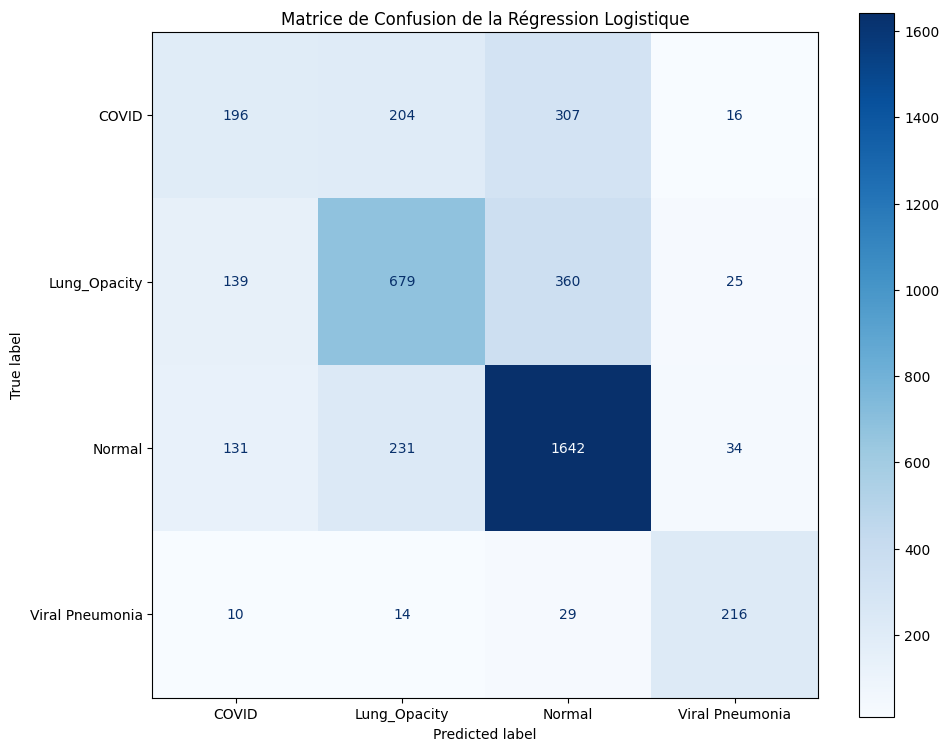


ℹ️ Explication: La régression logistique de scikit-learn est une tâche principalement CPU. Bien que des bibliothèques comme `cuML` puissent offrir des implémentations GPU pour la régression logistique, l'implémentation standard de scikit-learn utilise le CPU. L'utilisation du GPU direct pour `sklearn.linear_model.LogisticRegression` n'est donc pas applicable sans une modification significative de l'environnement ou de la bibliothèque.


In [15]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Utiliser le modèle `logistic_model` entraîné pour faire des prédictions sur l'ensemble de test
y_pred = logistic_model.predict(X_test)

print("✅ Prédictions effectuées sur l'ensemble de test.")

# 2 & 3. Afficher un rapport de classification détaillé
print("\n--- Rapport de Classification ---")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# 4 & 5. Calculer la matrice de confusion
cm = confusion_matrix(y_test, y_pred)

# 6, 7 & 8. Créer et afficher une visualisation de la matrice de confusion
print("\n--- Matrice de Confusion ---")
fig, ax = plt.subplots(figsize=(10, 8))
cmd = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
cmd.plot(ax=ax, cmap=plt.cm.Blues, values_format='d')
ax.set_title('Matrice de Confusion de la Régression Logistique')
plt.tight_layout()
plt.show()

print("\nℹ️ Explication: La régression logistique de scikit-learn est une tâche principalement CPU. Bien que des bibliothèques comme `cuML` puissent offrir des implémentations GPU pour la régression logistique, l'implémentation standard de scikit-learn utilise le CPU. L'utilisation du GPU direct pour `sklearn.linear_model.LogisticRegression` n'est donc pas applicable sans une modification significative de l'environnement ou de la bibliothèque.")